El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales simple, con un total de 6 capas.

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

2025-10-30 20:52:26.528747: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-30 20:52:26.943908: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-30 20:52:28.951494: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Funciones

In [4]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [5]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [4]:
    # Directorio con imagenes en tamaño original y  tamaño reducido
    d_original = 'E:/bandas/banda13/ene_may_5m'
    d_reducida = 'E:/bandas/banda13/ene_may_5m_reducida'

    #Llamado de función para redimensionar imágenes
    resize_npy_images(d_original, d_reducida, new_size=(480, 480))

    # Cargar las imágenes
    file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
    print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

    images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

    # Normalización
    all_pixels = np.concatenate([img.flatten() for img in images])
    global_min, global_max = np.min(all_pixels), np.max(all_pixels)

    images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
    images = [np.clip(img, 0, 1) for img in images]

    X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
    y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

    print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
    print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida


Procesando 3618 imágenes
Forma de X: (3617, 480, 480, 1)
Forma de y: (3617, 480, 480, 1)


Creación del modelo

In [6]:
semilla = 42
tf.random.set_seed(semilla)

model1 = Sequential([
    Conv2D(16, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    Conv2D(1, (1, 1), activation='linear', padding='same')  # SIN BatchNorm en la salida
])

model1.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
    )

print("Resumen del modelo:")
model1.summary()

# =====================================================
# CALLBACKS
# =====================================================
checkpoint = ModelCheckpoint(
    filepath="modelo1_best.h5",
    monitor="val_loss",  # Monitoreamos validación, no entrenamiento
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# =====================================================
# DIVISIÓN CRONOLÓGICA DE DATOS (SERIE DE TIEMPO)
# =====================================================
porc_validacion = 0.2
split_index = int(len(X) * (1 - porc_validacion))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"Tamaño entrenamiento: {len(X_train)} muestras")
print(f"Tamaño validación: {len(X_val)} muestras")

# Entrenamiento
print("Iniciando entrenamiento")
history1 = model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history1.history['loss'][-1]:.4f}")

Resumen del modelo:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 480, 480, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 480, 480, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 480, 480, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 480, 480, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 480, 480, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,401 (181.25 KB)

 Trainable params: 46,401 (181.25 KB)

...

724/724 ━━━━━━━━━━━━━━━━━━━━ 292s 403ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.1788 - root_mean_squared_error: 0.0724 - val_loss: 0.0070 - val_mean_absolute_percentage_error: 20.6733 - val_root_mean_squared_error: 0.0836
Epoch 5/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - loss: 0.0052 - mean_absolute_percentage_error: 14.9476 - root_mean_squared_error: 0.0721
Epoch 5: val_loss did not improve from 0.00699
724/724 ━━━━━━━━━━━━━━━━━━━━ 293s 404ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.1332 - root_mean_squared_error: 0.0723 - val_loss: 0.0070 - val_mean_absolute_percentage_error: 21.0917 - val_root_mean_squared_error: 0.0838
Epoch 6/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - loss: 0.0052 - mean_absolute_percentage_error: 14.8570 - root_mean_squared_error: 0.0718
Epoch 6: val_loss did not improve from 0.00699
724/724 ━━━━━━━━━━━━━━━━━━━━ 292s 404ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.0810 - root_mean_squared_error: 0.0721 - 

724/724 ━━━━━━━━━━━━━━━━━━━━ 293s 405ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.0642 - root_mean_squared_error: 0.0720 - val_loss: 0.0070 - val_mean_absolute_percentage_error: 21.2542 - val_root_mean_squared_error: 0.0835
Epoch 8/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.7577 - root_mean_squared_error: 0.0715
Epoch 8: val_loss improved from 0.00698 to 0.00691, saving model to modelo1_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 292s 403ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.0401 - root_mean_squared_error: 0.0719 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 21.0937 - val_root_mean_squared_error: 0.0831
Epoch 9/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.7419 - root_mean_squared_error: 0.0714
Epoch 9: val_loss improved from 0.00691 to 0.00690, saving model to modelo1_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 292s 404ms/step - loss: 0.0052 - mean_absolute_percentage_error: 15.0188 - root_mean_squared_error: 0.0718 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 20.9129 - val_root_mean_squared_error: 0.0831
Epoch 10/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.7318 - root_mean_squared_error: 0.0714
Epoch 10: val_loss did not improve from 0.00690
724/724 ━━━━━━━━━━━━━━━━━━━━ 292s 403ms/step - loss: 0.0051 - mean_absolute_percentage_error: 15.0008 - root_mean_squared_error: 0.0717 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 20.8484 - val_root_mean_squared_error: 0.0831
Epoch 11/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.7321 - root_mean_squared_error: 0.0714
Epoch 11: val_loss did not improve from 0.00690
724/724 ━━━━━━━━━━━━━━━━━━━━ 291s 402ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.9986 - root_mean_squared_error: 0.071

724/724 ━━━━━━━━━━━━━━━━━━━━ 292s 403ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.9666 - root_mean_squared_error: 0.0716 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 20.9611 - val_root_mean_squared_error: 0.0830
Epoch 14/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.7261 - root_mean_squared_error: 0.0712
Epoch 14: val_loss did not improve from 0.00690
724/724 ━━━━━━━━━━━━━━━━━━━━ 292s 404ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.9602 - root_mean_squared_error: 0.0715 - val_loss: 0.0069 - val_mean_absolute_percentage_error: 21.0414 - val_root_mean_squared_error: 0.0830
Epoch 15/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.7253 - root_mean_squared_error: 0.0712
Epoch 15: val_loss did not improve from 0.00690
724/724 ━━━━━━━━━━━━━━━━━━━━ 292s 403ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.9690 - root_mean_squared_error: 0.071

Valores de las metricas

In [8]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model1.evaluate(X_train, y_train, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 48s 528ms/step - loss: 0.0051 - mean_absolute_percentage_error: 14.6593 - root_mean_squared_error: 0.0711
Pérdida (MSE): 0.0051
RMSE: 0.0711
MAPE: 14.6593


In [9]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model1.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 585ms/step - loss: 0.0069 - mean_absolute_percentage_error: 20.9611 - root_mean_squared_error: 0.0830
Pérdida (MSE): 0.0069
RMSE: 0.0830
MAPE: 20.9611


RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0051, RMSE final: 0.0712, MAPE final: 14.9176
Validación    - Loss final: 0.0070, RMSE final: 0.0835, MAPE final: 21.2938


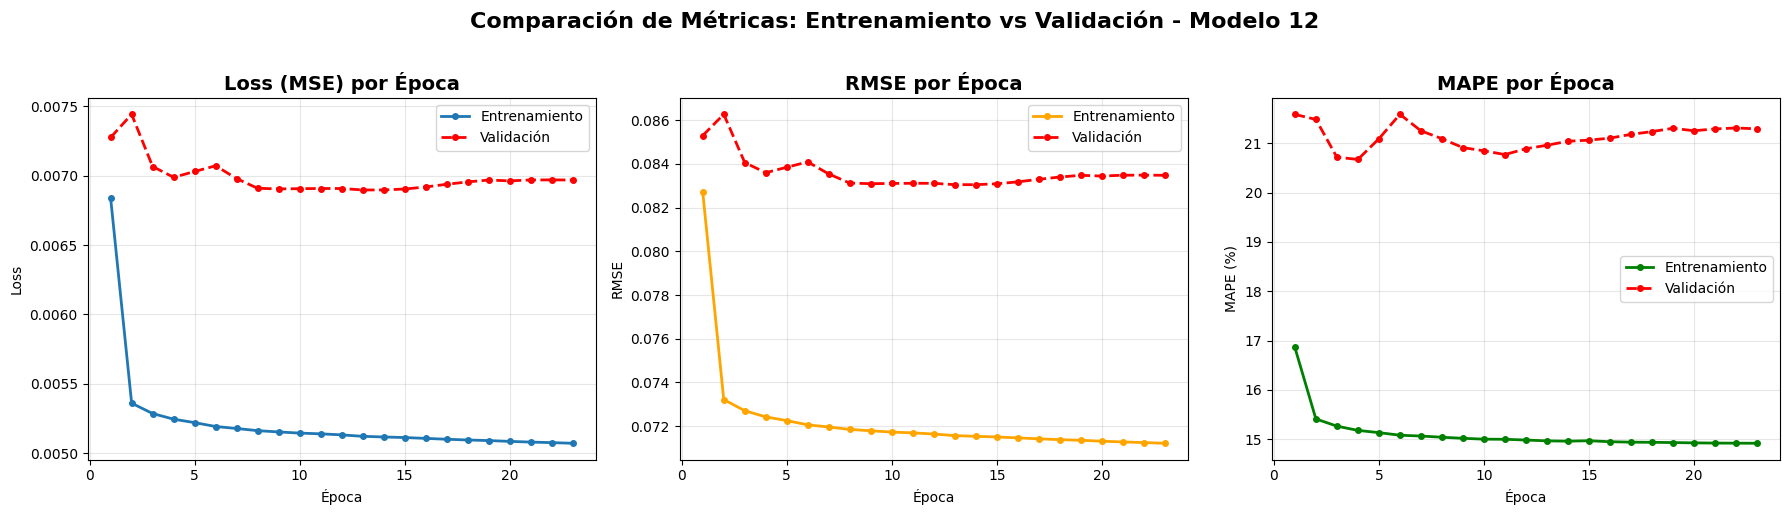

In [10]:
# Extraer métricas del historial (entrenamiento y validación)
loss = history1.history['loss']
val_loss = history1.history['val_loss']

rmse = history1.history['root_mean_squared_error']
val_rmse = history1.history['val_root_mean_squared_error']

mape = history1.history['mean_absolute_percentage_error']
val_mape = history1.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 12',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Visualización de imagenes

91/91 ━━━━━━━━━━━━━━━━━━━━ 48s 525ms/step


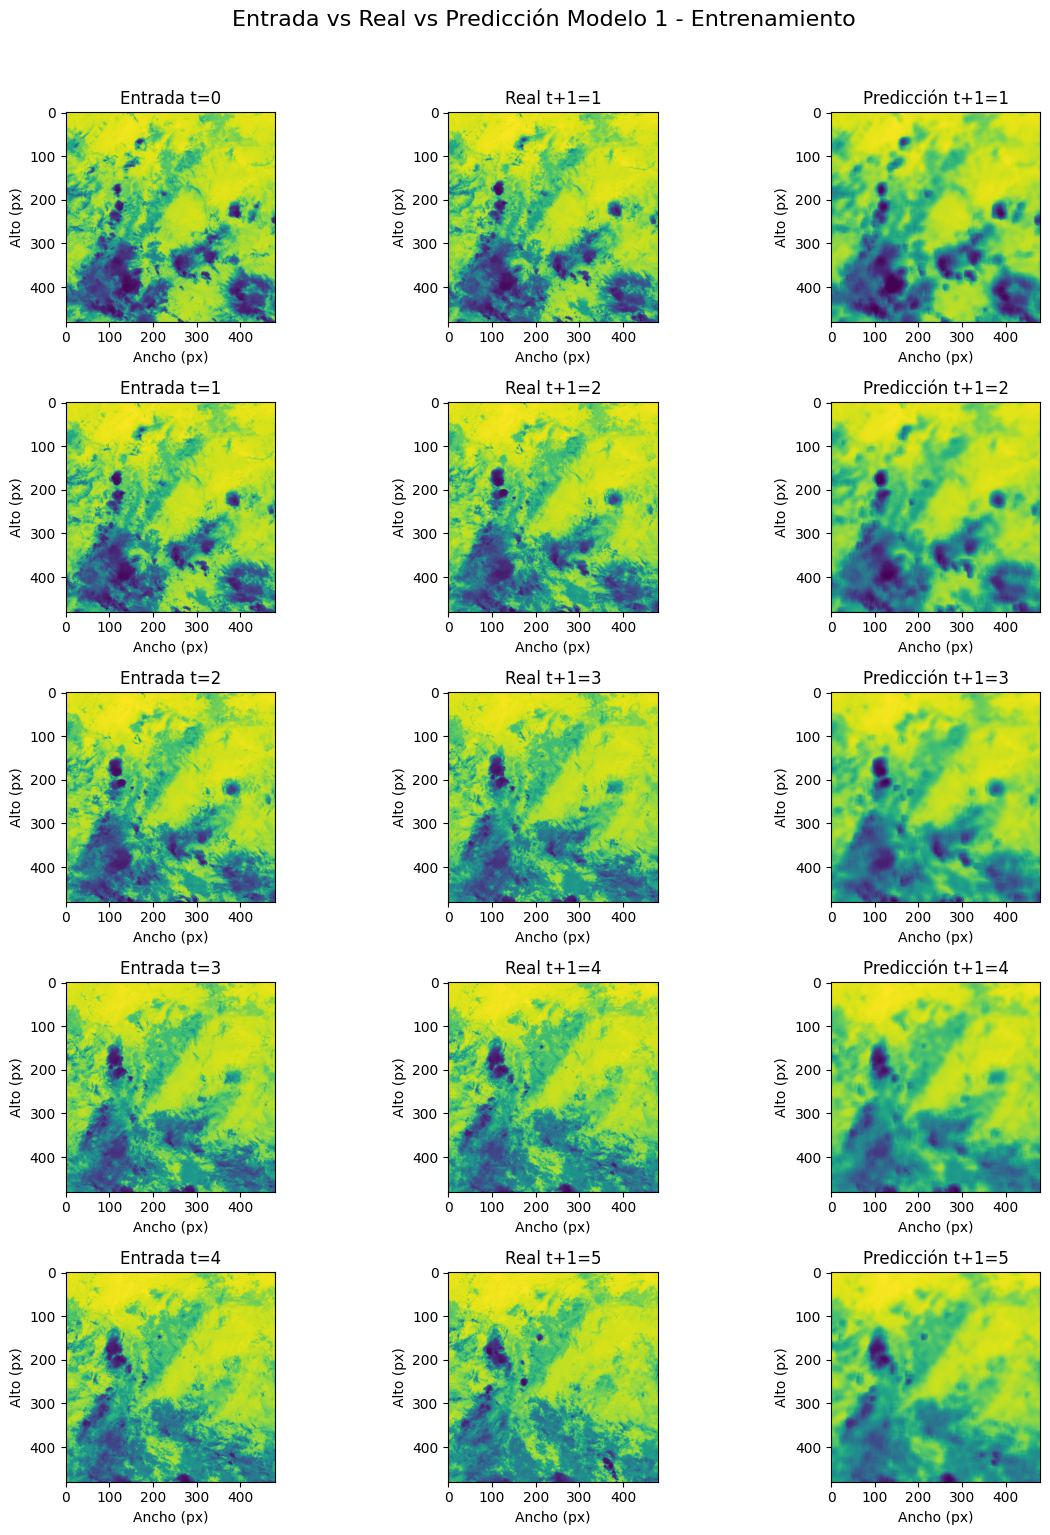

In [12]:
y_pred1 = model1.predict(X_train)  # Genera las predicciones
mostrar_resultados(
    X_train, y_train, y_pred1, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Prueba

In [6]:
# Directorio original y reducido
d_jun_1m = '/home/fisica/bandas/banda13/jun_1m'
d_jun_1m_red = '/home/fisica/bandas/banda13/jun_1m_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_jun_1m, d_jun_1m_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_jun_1m_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_test = [np.load(os.path.join(d_jun_1m_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]


X_test = np.array(images_test[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_test = np.array(images_test[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_test.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_test.shape}")  # Imprime la forma del array de salida

Procesando 716 imágenes
Forma de X: (715, 480, 480, 1)
Forma de y: (715, 480, 480, 1)


2025-10-30 20:59:24.857382: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 658944000 exceeds 10% of free system memory.
2025-10-30 20:59:25.753225: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 29491200 bytes after encountering the first element of size 29491200 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-10-30 20:59:25.918271: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 471859200 exceeds 10% of free system memory.
2025-10-30 20:59:26.135834: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 943718400 exceeds 10% of free system memory.
2025-10-30 20:59:26.751516: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 1887436800 exceeds 10% of free system memory.


23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step


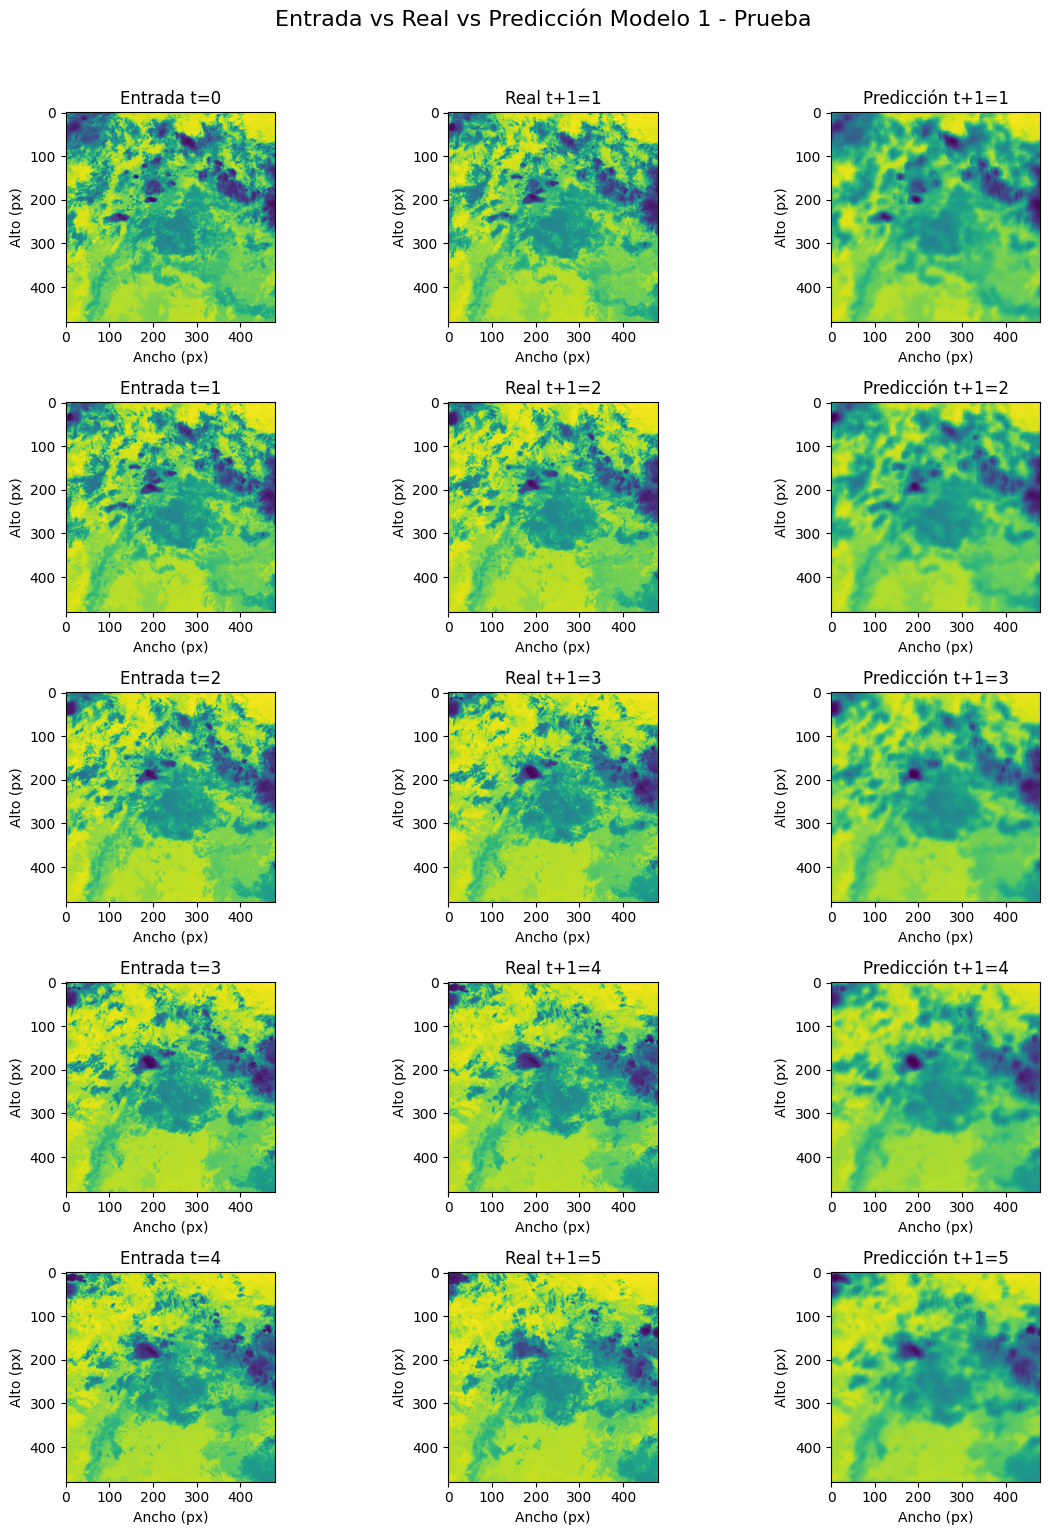

In [9]:
from tensorflow.keras.models import load_model
# Cargar el mejor modelo guardado
modelo_cargado = load_model("modelo1_best.h5", compile=False)

y_pred_test = modelo_cargado.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_pred_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Metricas de prueba

In [11]:
# Obtener las métricas del modelo en el conjunto de prueba
modelo_cargado.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

loss, rmse, mape = modelo_cargado.evaluate(X_test, y_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - loss: 0.0087 - mean_absolute_percentage_error: 22.3196 - root_mean_squared_error: 0.0935
Pérdida (MSE): 0.0087
RMSE: 0.0935
MAPE: 22.3196


Visualización de imagenes con conjunto de prueba

12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step


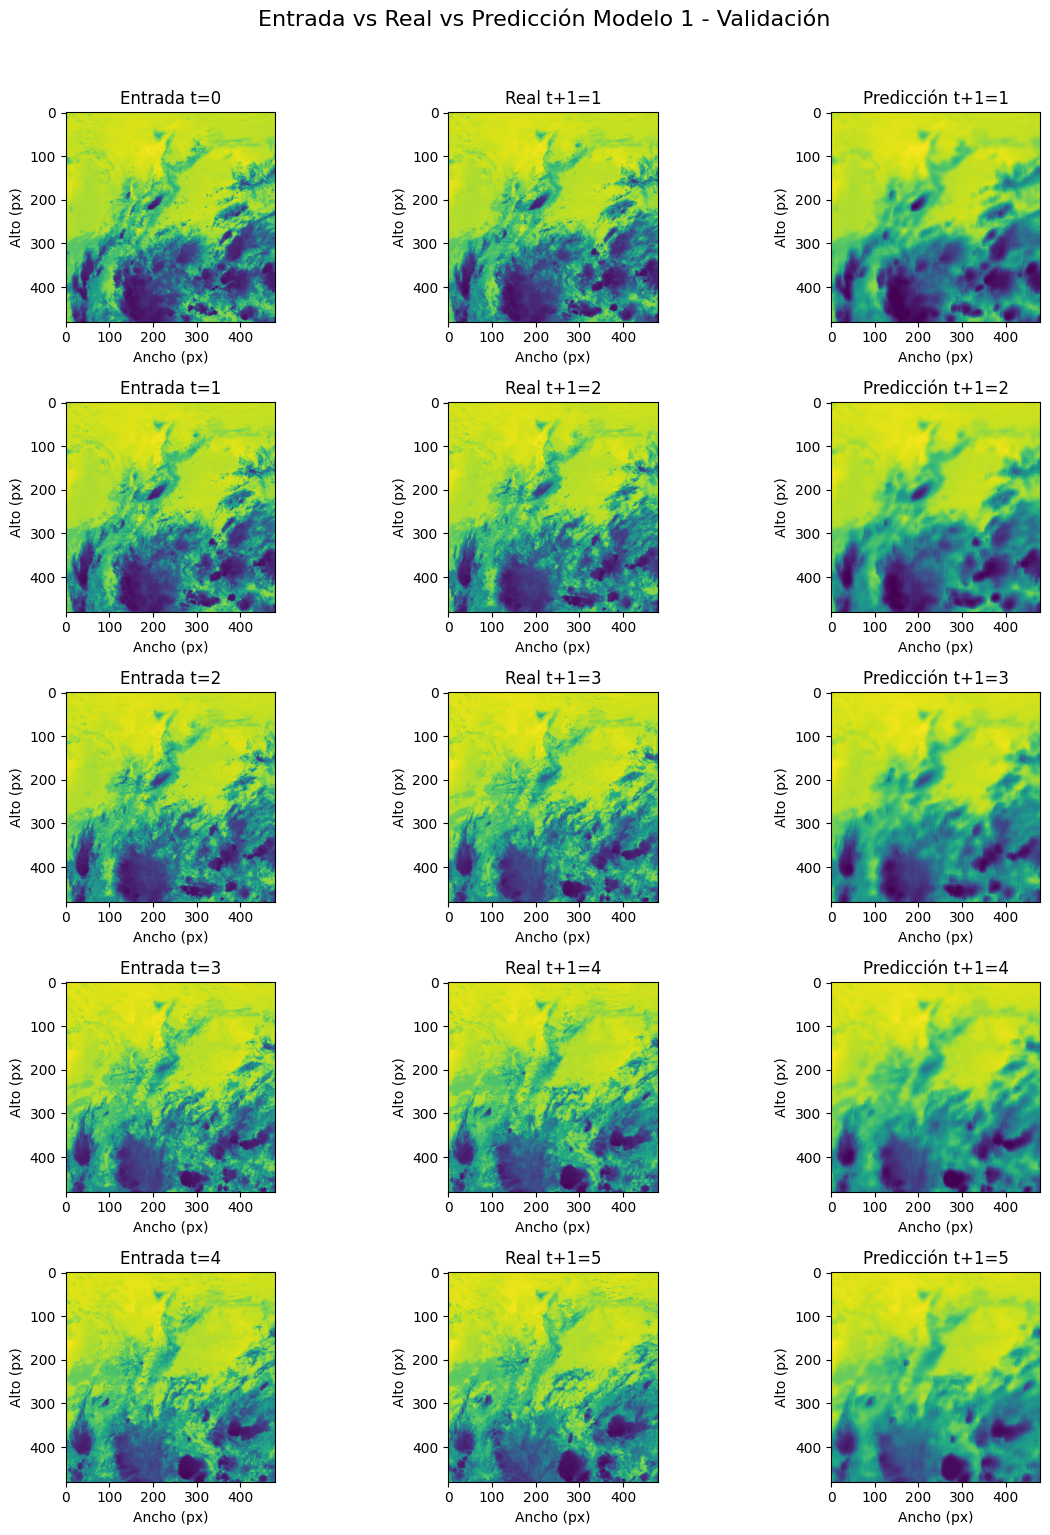

In [15]:
y_pred1_test = model1.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_pred1_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 1 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)